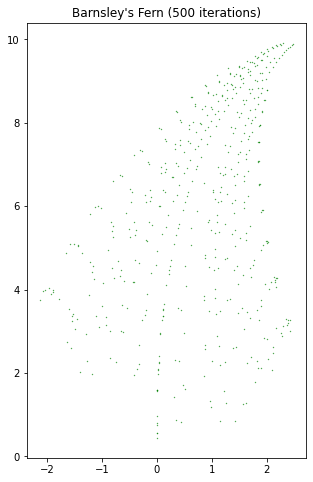

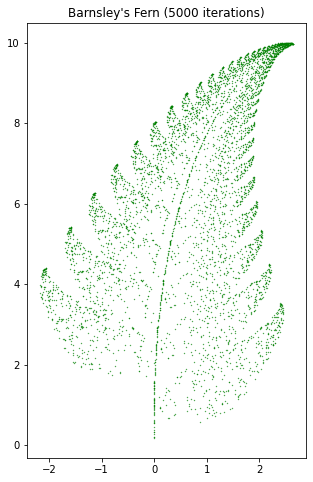

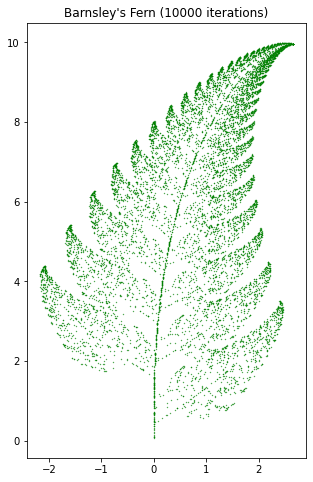

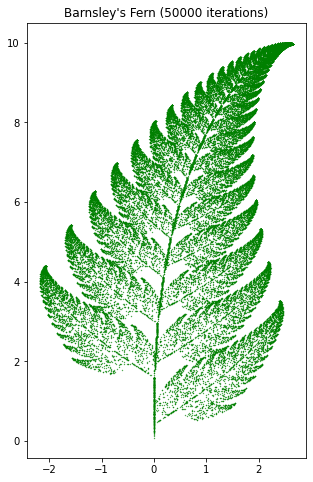

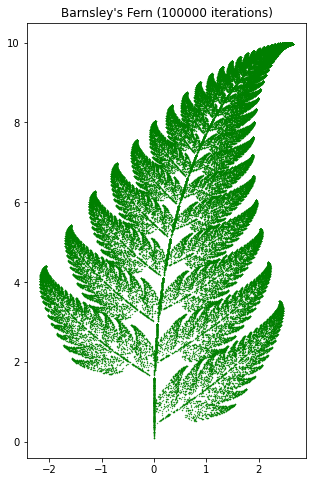

Observed frequencies: [0.00974 0.85    0.07095 0.06931]
Expected probabilities: [0.01, 0.85, 0.07, 0.07]
Chi-square Test Result:
Chi2 statistic = 2.6454285714285644
p-value = 0.4495809338646315


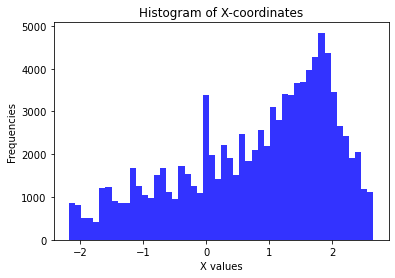

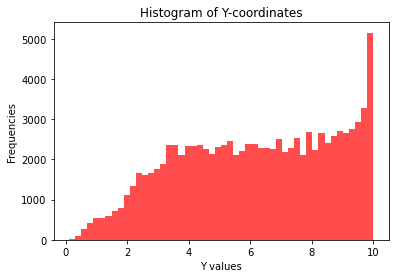

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import chisquare

#probabilities 
probabilities = [0.01, 0.85, 0.07, 0.07]

#matrices transformation
transformations = [
    np.array([[0, 0], [0, 0.16]]),
    np.array([[0.85, 0.04], [-0.04, 0.85]]),
    np.array([[0.20, -0.26], [0.23, 0.22]]),
    np.array([[-0.15, 0.28], [0.26, 0.24]])
]

# Shift vectors
translation_vector = [
    np.array([0, 0]),
    np.array([0, 1.6]),
    np.array([0, 1.6]),
    np.array([0, 0.44])
]
def generate_values(n):              
    x, y = 0, 0
    values = []                        
    repeatation = []                        

    for _ in range(n):
        r = np.random.choice([0,1,2,3], p=probabilities)
        M = transformations[r]               
        shift_vec = translation_vector[r]              
        new = M.dot([x, y]) + shift_vec      
        x, y = new                     
        values.append([x, y])           
        repeatation.append(r)                

    return np.array(values), repeatation

for N in [500, 5000, 10000, 50000, 100000]:
    vals, repeatation = generate_values(N)

    plt.figure(figsize=(5, 8))
    plt.scatter(vals[:, 0], vals[:, 1], s=0.1, color="green")
    plt.title(f"Barnsley's Fern ({N} iterations)")
    plt.savefig(f"barnsley_fern_{N}.png", dpi=300)
    plt.show()


values, repeatation = vals, repeatation


counts_transf = Counter(repeatation)
observes = np.array([counts_transf[i] for i in range(4)])
observs_freq = observes / 100000 

chisq, p_vals = chisquare(f_obs=observes, f_exp = np.array(probabilities) * 100000)

print("Observed frequencies:", observs_freq)
print("Expected probabilities:", probabilities)
print("Chi-square Test Result:")
print("Chi2 statistic =", chisq)
print("p-value =", p_vals)


plt.figure()
plt.hist(values[:, 0], bins=50, color="blue", alpha=0.8)
plt.title("Histogram of X-coordinates")
plt.xlabel("X values")
plt.ylabel("Frequencies")
plt.savefig("histo_x", dpi=300)
plt.show()

plt.figure()
plt.hist(values[:, 1], bins=50, color="red", alpha=0.7)
plt.title("Histogram of Y-coordinates")
plt.xlabel("Y values")
plt.ylabel("Frequencies")
plt.savefig("hist_y", dpi=300)
plt.show()


with open("results.text", "w") as f:
    f.write("Observed frequencies: " + str(observs_freq) + "\n")
    f.write("Expected probabilities: " + str(probabilities) + "\n")
    f.write("Chi-square statistic: " + str(chisq) + "\n")
    f.write("p-values: " + str(p_vals) + "\n")
